<div style="text-align:center">
<img src="img/montecarlointro.png">
</div>

# Introduction

Here I will test various simulations using the Monte Carlo method, and A.I.

# Summary


01. <b>Monte carlo simulation in a shop environment </b>
    - Abstract
    - Instance
    - Math model
    - Docplex solution
02. <b>Monte carlo simulation in a factory environment involving failure</b>
    - Abstract
    - Instance
    - Math model
    - Docplex solution




# <b>01.  Monte carlo simulation in a shop environment </b>



<div style="text-align:center">
<img src="img/store-grocery-shop-building-isolated-white-background_1284-14054.avif" width="400" height="400">
</div>

<div style="text-align:center">
<img src="img/deepseek.png" width="200"/>
</div>


## Abstract

<i>Can you provide a simple monte carlo simulation in a shop environment, including the math model and the python code ?  </i>

<div style = "background:green;color:white">
A Monte Carlo simulation is essentially a "what-if" machine. In a shop environment, it’s perfect for predicting things like daily revenue or customer wait times when you don't have a fixed schedule, but you do have historical averages.

Let’s look at a simulation for Daily Revenue in a small coffee shop.
</div>

## Instance

 <table style="margin: 0px auto;">

<tr>
    <td>Average number of customers</td>
    <td>50 </td>

</tr>
<tr>
    <td>Average spend</td>
    <td>15</td>

</tr>
<tr>
    <td>Spend standard deviation</td>
    <td>5</td>

</tr>
<tr>
    <td>Number of simulations</td>
    <td>10000</td>

</tr>
</table>

## Math model

## Python solution

Expected Average Revenue: $748.86
5th Percentile (Worst Case): $569.43
95th Percentile (Best Case): $937.30


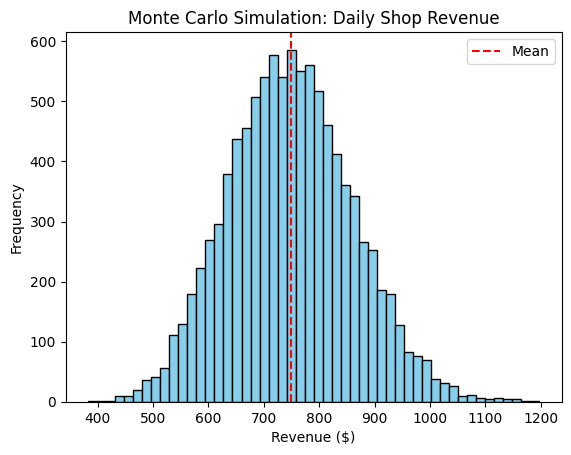

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration ---
avg_customers_per_day = 50  # Lambda
avg_spend = 15.0            # Mu
spend_std_dev = 5.0         # Sigma
num_simulations = 10000     # How many "days" to simulate

daily_revenues = []

# --- Simulation Loop ---
for _ in range(num_simulations):
    # 1. Determine how many customers showed up today
    num_customers = np.random.poisson(avg_customers_per_day)
    
    # 2. Simulate what each of those customers spent
    customer_orders = np.random.normal(avg_spend, spend_std_dev, num_customers)
    
    # 3. Sum it up for the day
    daily_revenues.append(np.sum(customer_orders))

# --- Results ---
print(f"Expected Average Revenue: ${np.mean(daily_revenues):.2f}")
print(f"5th Percentile (Worst Case): ${np.percentile(daily_revenues, 5):.2f}")
print(f"95th Percentile (Best Case): ${np.percentile(daily_revenues, 95):.2f}")

# Visualization
plt.hist(daily_revenues, bins=50, color='skyblue', edgecolor='black')
plt.title('Monte Carlo Simulation: Daily Shop Revenue')
plt.xlabel('Revenue ($)')
plt.ylabel('Frequency')
plt.axvline(np.mean(daily_revenues), color='red', linestyle='dashed', label='Mean')
plt.legend()
plt.show()